In [18]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/sebastienattia/Documents/NYU/Classes/Semester 2/MarketToModel/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [19]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [20]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.30618348522779953),
 'dalpha': np.float64(2.7715036300362685),
 'dbeta': np.float64(-0.7638534888724806),
 'drho': np.float64(0.004772549754301578),
 'dnu': np.float64(0.01776098097732011),
 'dforward': np.float64(-2.3900323325525674),
 'dstrike': np.float64(0.8445905717391485),
 'd_ln_sigma_d_alpha': np.float64(2.7715036300362685),
 'd_ln_sigma_d_beta': np.float64(-0.7638534888724806),
 'd_ln_sigma_d_rho': np.float64(0.004772549754301578),
 'd_ln_sigma_d_nu': np.float64(0.01776098097732011),
 'd_ln_sigma_d_forward': np.float64(-2.3900323325525674),
 'd_ln_sigma_d_strike': np.float64(0.8445905717391485),
 'd_ln_sigma_d_tte': np.float64(0.004856958620874264)}

# 2. Detection of Negative Density

The parameters set is:

In [21]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

[0.0001     0.00031263 0.00052525 0.00073788 0.0009505  0.00116313
 0.00137575 0.00158838 0.001801   0.00201363 0.00222625 0.00243888
 0.0026515  0.00286413 0.00307675 0.00328938 0.003502   0.00371463
 0.00392725 0.00413988 0.00435251 0.00456513 0.00477776 0.00499038
 0.00520301 0.00541563 0.00562826 0.00584088]


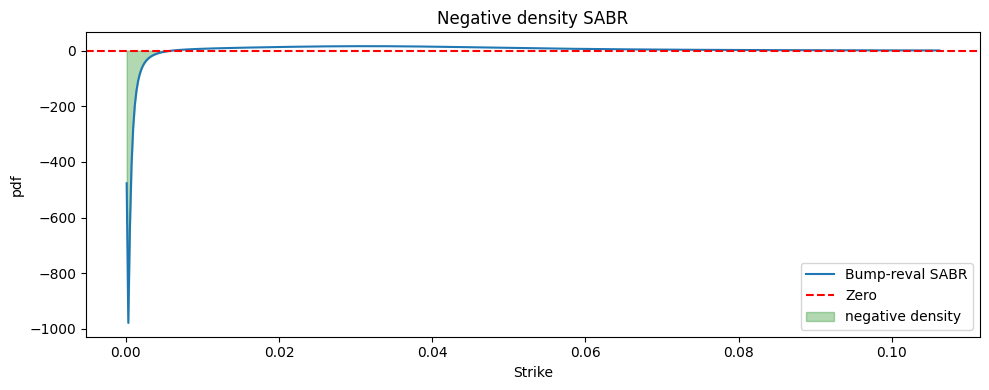

In [22]:
import numpy as np
import matplotlib.pyplot as plt

strikes = np.linspace(1e-4, 3*forward, 500)

pdfs = []

for K in strikes:
    eps = 1e-5
    c_up = SABRAnalytics.european_option_alpha(forward, K+eps, tte, CallOrPut.CALL, alpha, beta, rho, nu, shift)[SimpleMetrics.PV]
    c_mid = SABRAnalytics.european_option_alpha(forward, K, tte, CallOrPut.CALL, alpha, beta, rho, nu, shift)[SimpleMetrics.PV]
    c_down = SABRAnalytics.european_option_alpha(forward, K-eps, tte, CallOrPut.CALL, alpha, beta, rho, nu, shift)[SimpleMetrics.PV]

    pdf = (c_up - 2*c_mid +c_down) / eps**2
    pdfs.append(pdf)

pdfs = np.array(pdfs)
negative_v = pdfs < 0
negative_K = strikes[negative_v]

print(negative_K)

plt.figure(figsize=(10,4))
plt.plot(strikes, pdfs, label= "Bump-reval SABR")
plt.axhline(0, color='red', linestyle='--', label='Zero')
plt.fill_between(strikes, pdfs, 0, where=(negative_v), color = "green", alpha= 0.3, label = "negative density")
plt.xlabel("Strike")
plt.ylabel("pdf")
plt.title("Negative density SABR")
plt.legend()
plt.tight_layout()
plt.show()


# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

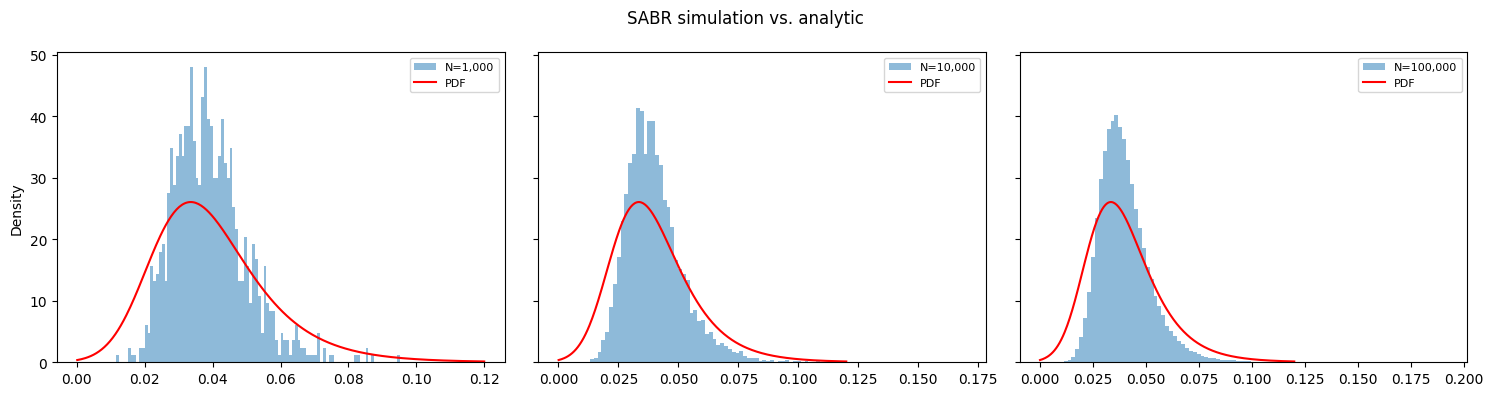

In [23]:

def simulate(forward, alpha, beta, rho, nu, tte, n_steps, n_paths, seed=42):
    np.random.seed(seed)
    df=tte/n_steps
    F=np.full(n_paths, forward)
    a=np.full(n_paths, alpha)

    for _ in range(n_steps):
        Z1, Z2 = np.random.randn(n_paths), np.random.randn(n_paths)
        W1 = Z1
        W2 = rho *Z1 +np.sqrt(1-rho**2)* Z2
        F = F+a*np.maximum(F,0)**beta *np.sqrt(df) *W1
        a=a*np.exp(-0.5 * nu**2 *df +nu *np.sqrt(df)*W2)
    return F

alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
tte = 0.5

def sabr_pdf(forward, alpha, beta, rho, nu, shift, tte, strikes, eps=1e-5):
    pdf = []
    for K in strikes:
        c = lambda k: SABRAnalytics.european_option_alpha(forward, k, tte, CallOrPut.CALL, alpha, beta, rho, nu, shift)[SimpleMetrics.PV]
        pdf.append((c(K+eps) - 2*c(K) + c(K-eps))/ eps**2)
    
    return np.array(pdf)

strikes = np.linspace(1e-4, 3*forward, 300)
pdf_analytics = sabr_pdf(forward, alpha, beta, rho, nu,shift, tte, strikes)

fig, axes = plt.subplots(1,3, figsize = (15,4), sharey=True)
for ax, n_paths in zip(axes,[1_000, 10_000, 100_000]):
    terminals = simulate(forward, alpha, beta, rho, nu, tte, 500, n_paths)
    ax.hist(terminals[terminals>0], bins=100, density=True, alpha=0.5, label = f'N={n_paths:,}')
    ax.plot(strikes, np.maximum(pdf_analytics, 0), "r-", label = "PDF")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.suptitle("SABR simulation vs. analytic")
plt.tight_layout()
plt.show()

# 4. Quantile Map


In [24]:
from scipy.interpolate import PchipInterpolator
from scipy.stats import norm, qmc

S1_0, sigma1, beta1, nu1, rho1 = 0.03, 0.01, 0.5, 0.2, 0.25
S2_0, sigma2, beta2, nu2, rho2 = 0.05, 0.012, 0.5, 0.15, 0.45
rho_12, K, tte = 0.9, 0.001, 1.0

alpha1 = SABRAnalytics.alpha_from_atm_normal_sigma(S1_0, tte, sigma1, beta1, rho1, nu1)[SabrMetrics.ALPHA]
alpha2 = SABRAnalytics.alpha_from_atm_normal_sigma(S2_0, tte, sigma2, beta2, rho2, nu2)[SabrMetrics.ALPHA]

def interpolator(fwd, alpha, beta, rho, nu, tte, n=300, eps=1e-4):
    strikes = np.linspace(fwd*0.05, 3*fwd, n)
    pdf = []
    for K_ in strikes:
        c = lambda k: SABRAnalytics.european_option_alpha(
            fwd, k, tte, CallOrPut.CALL, alpha, beta, rho, nu, 0.0
        )[SimpleMetrics.PV]
        pdf.append(max((c(K_+eps) - 2*c(K_) + c(K_-eps)) / eps**2, 0.0))
    cdf = np.cumsum(pdf) * (strikes[1] - strikes[0])
    cdf /= cdf[-1]
    y = norm.ppf(np.clip(cdf, 1e-6, 1-1e-6))
    mask = np.concatenate(([True], np.diff(y)>0))
    return PchipInterpolator(y[mask], strikes[mask])

I1 = interpolator(S1_0, alpha1, beta1, rho1, nu1, tte)
I2 = interpolator(S2_0, alpha2, beta2, rho2, nu2, tte)

N = 131072
B = np.linalg.cholesky([[1.0, rho_12], [rho_12, 1.0]])
s = qmc.Sobol(d=2, scramble=True, seed=42).random(N)
y = (B @ norm.ppf(np.clip(s, 1e-4, 1-1e-4)).T).T
y1_min, y1_max = I1.x[0], I1.x[-1]
y2_min, y2_max = I2.x[0], I2.x[-1]

S1 = I1(np.clip(y[:,0], y1_min, y1_max))
S2 = I2(np.clip(y[:,1], y2_min, y2_max))

price = np.mean(np.maximum(S1 - S2 - K, 0.0))
print(f"Spread option price: {price:.8f}")

Spread option price: 0.00000007


/var/folders/b0/14_vbkjn42sfxj50twkd9_xc0000gn/T/ipykernel_52544/264384930.py:31: RuntimeWarning: divide by zero encountered in matmul
  y = (B @ norm.ppf(np.clip(s, 1e-4, 1-1e-4)).T).T
/var/folders/b0/14_vbkjn42sfxj50twkd9_xc0000gn/T/ipykernel_52544/264384930.py:31: RuntimeWarning: overflow encountered in matmul
  y = (B @ norm.ppf(np.clip(s, 1e-4, 1-1e-4)).T).T
/var/folders/b0/14_vbkjn42sfxj50twkd9_xc0000gn/T/ipykernel_52544/264384930.py:31: RuntimeWarning: invalid value encountered in matmul
  y = (B @ norm.ppf(np.clip(s, 1e-4, 1-1e-4)).T).T


# Bonus
To validate our answer, we can run a joint Euler Maruyama simulation of two correlated SABR processes simultaneously.

In [25]:
def simulate_joint(S1_0, alpha1, beta1, rho1, nu1, S2_0, alpha2, beta2, rho2, nu2, rho12, tte, n_steps, n_paths, seed=42):
    np.random.seed(seed)
    df = tte/n_steps
    F1, a1 = np.full(n_paths, S1_0), np.full(n_paths, alpha1)
    F2, a2 = np.full(n_paths, S2_0), np.full(n_paths, alpha2)

    for _ in range(n_steps):
        Z = np.random.randn(4, n_paths)
        W1_F = Z[0]
        W1_sig = rho1 * Z[0] + np.sqrt(1-rho1**2) * Z[1]
        W2_F = rho12 * Z[0] + np.sqrt(1-rho12**2) * Z[2]
        W2_sig = rho2 * W2_F + np.sqrt(1-rho2**2) * Z[3]
        F1 = F1 +a1 * np.maximum(F1, 0)**beta1 * np.sqrt(df) * W1_F
        a1 = a1 * np.exp(-0.5*nu1**2*df + nu1* np.sqrt(df)*W1_sig)
        F2 = F2 + a2 *np.maximum(F2,0)**beta2 *np.sqrt(df) * W2_F
        a2 = a2 * np.exp(-0.5*nu2**2*df + nu2*np.sqrt(df)*W2_sig)
    return F1, F2

F1, F2 = simulate_joint(S1_0, alpha1, beta1, rho1, nu1, S2_0, alpha2, beta2, rho2, nu2, rho_12, tte, 500, 500000)
payoff = np.maximum(F1-F2-K, 0.0)
price_mc = np.mean(payoff)
std_mc = np.std(payoff) / np.sqrt(500000)

print(f"Quantile map: {price:.8f} | MC: {price_mc:.8f} ± {1.96*std_mc:.8f}")

Quantile map: 0.00000007 | MC: 0.00000064 ± 0.00000016


# Assignment 8 extra - Closest semi positive definite to C

In [ ]:
import numpy as np
from scipy.optimize import minimize

C = np.array([[1, 0.9, 0.9],
              [0.9, 1, -0.9],
              [0.9, -0.9, 1]])

def vec_to_matrix(x):
    return np.array([[x[0], x[1], x[2]],
                      [x[1], x[3], x[4]],
                      [x[2], x[4], x[5]]])

def obj(x):
    return np.linalg.norm(vec_to_matrix(x) - C, 'fro')**2 # frobenius norm

constraints = [
    {"type": "ineq", "fun": lambda x: np.linalg.eigvalsh(vec_to_matrix(x))},
    {"type": "eq", "fun": lambda x: np.array([x[0]-1, x[3]-1, x[5]-1])}
]

x0 = C[np.tril_indices(3)]
result = minimize(obj, x0, constraints = constraints, method = "SLSQP")
print(vec_to_matrix(result.x)) # final results

[[ 1.          0.49999591  0.5000003 ]
 [ 0.49999591  1.         -0.50000379]
 [ 0.5000003  -0.50000379  1.        ]]
